<a href="https://colab.research.google.com/github/Dragnel25/timeseriesdoan/blob/main/notebooks_04_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

--- BẢNG KẾT QUẢ ĐÁNH GIÁ (TẬP TEST) ---
1. Baseline (Lag 24h) | MAE: 925.11 | RMSE: 1220.46 | MAPE: 6.23%
2. XGBoost (Fourier)  | MAE: 160.87 | RMSE: 211.64 | MAPE: 1.09%
3. LSTM (Deep L.)     | MAE: 1146.51 | RMSE: 1428.38 | MAPE: 7.87%


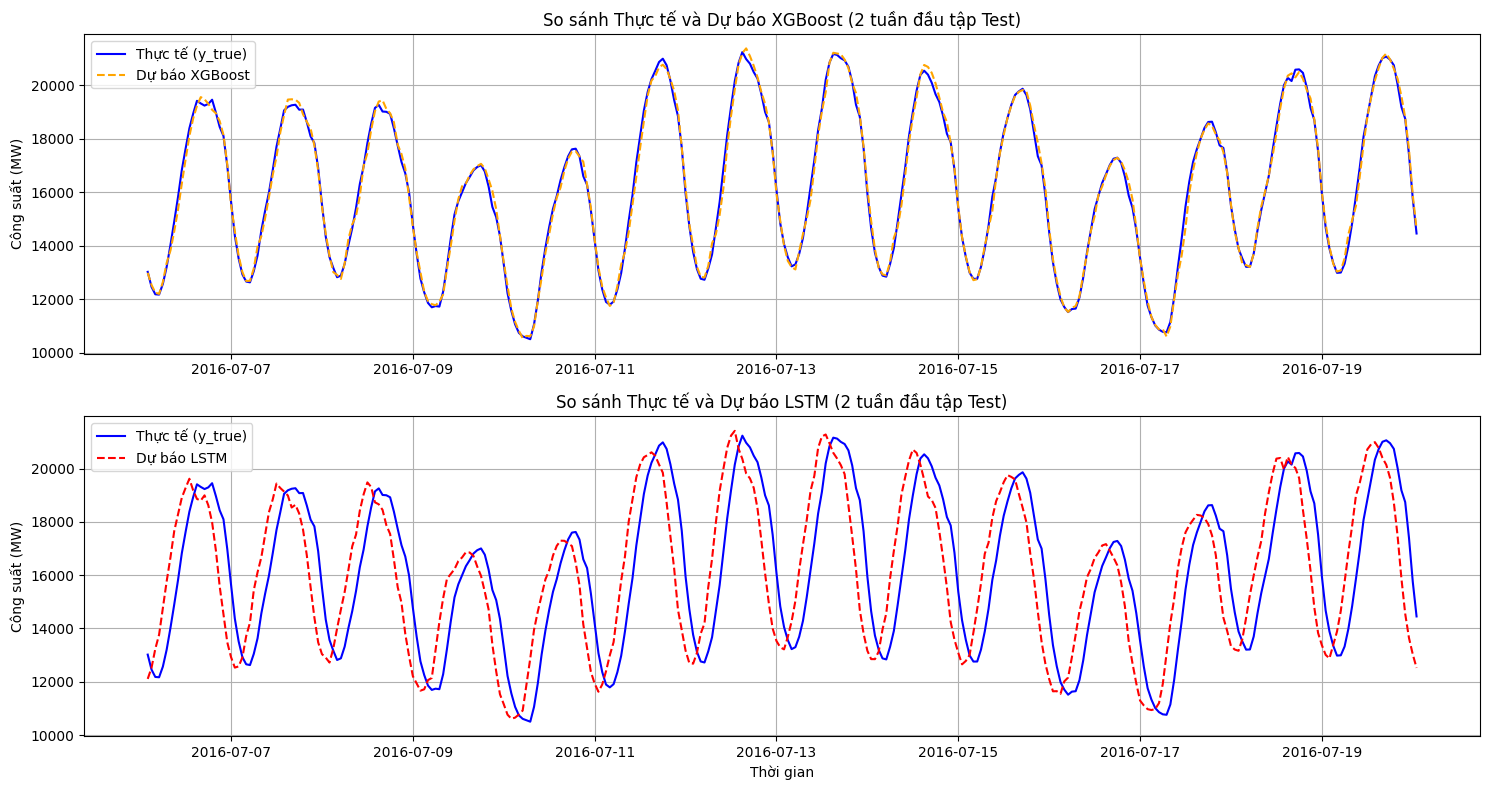

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.colab import drive

# 1. ĐỌC KẾT QUẢ DỰ BÁO TỪ FILE 03 TRÊN DRIVE
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/AEP_predictions.csv', index_col='Datetime', parse_dates=True)

# 2. HÀM TÍNH TOÁN METRICS
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

mae_base, rmse_base, mape_base = calculate_metrics(df['y_true'], df['y_pred_baseline'])
mae_xgb, rmse_xgb, mape_xgb = calculate_metrics(df['y_true'], df['y_pred_xgb'])
mae_lstm, rmse_lstm, mape_lstm = calculate_metrics(df['y_true'], df['y_pred_lstm'])

# 3. IN BẢNG KẾT QUẢ ĐÁNH GIÁ CỦA ĐỦ 3 MÔ HÌNH
print("\n--- BẢNG KẾT QUẢ ĐÁNH GIÁ (TẬP TEST) ---")
print(f"1. Baseline (Lag 24h) | MAE: {mae_base:.2f} | RMSE: {rmse_base:.2f} | MAPE: {mape_base:.2f}%")
print(f"2. XGBoost (Fourier)  | MAE: {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | MAPE: {mape_xgb:.2f}%")
print(f"3. LSTM (Deep L.)     | MAE: {mae_lstm:.2f} | RMSE: {rmse_lstm:.2f} | MAPE: {mape_lstm:.2f}%")

# 4. VẼ ĐỒ THỊ SO SÁNH (Cắt 2 tuần đầu)
plot_len = 24 * 14
plt.figure(figsize=(15, 8))

# Đồ thị 1: XGBoost
plt.subplot(2, 1, 1)
plt.plot(df.index[:plot_len], df['y_true'].values[:plot_len], label='Thực tế (y_true)', color='blue')
plt.plot(df.index[:plot_len], df['y_pred_xgb'].values[:plot_len], label='Dự báo XGBoost', color='orange', linestyle='--')
plt.title("So sánh Thực tế và Dự báo XGBoost (2 tuần đầu tập Test)")
plt.ylabel("Công suất (MW)")
plt.legend()
plt.grid(True)

# Đồ thị 2: LSTM
plt.subplot(2, 1, 2)
plt.plot(df.index[:plot_len], df['y_true'].values[:plot_len], label='Thực tế (y_true)', color='blue')
plt.plot(df.index[:plot_len], df['y_pred_lstm'].values[:plot_len], label='Dự báo LSTM', color='red', linestyle='--')
plt.title("So sánh Thực tế và Dự báo LSTM (2 tuần đầu tập Test)")
plt.xlabel("Thời gian")
plt.ylabel("Công suất (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()